# <center><span style='color:red'><b>PC + EOF (without normalisation)</b></span></center>

## Imports
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import uniform_filter1d
from eofs.xarray import Eof
import pandas as pd       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Open with xarray
data = xr.open_zarr('/gws/nopw/j04/coast_hack/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()

# Print a summary of dataset
print(data)

<xarray.Dataset> Size: 408MB
Dimensions:    (time: 10408, latitude: 81, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
  * longitude  (longitude) float64 968B -100.0 -99.0 -98.0 ... 18.0 19.0 20.0
  * latitude   (latitude) float64 648B 0.0 1.0 2.0 3.0 ... 77.0 78.0 79.0 80.0
Data variables:
    mlotst     (time, latitude, longitude) float32 408MB 10.53 10.53 ... nan nan


## Clean and process data
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [3]:
# ----------------------------------
# Ensure required dimensions
# ----------------------------------
required_dims = {"time", "latitude", "longitude"}
if not required_dims.issubset(data.dims):
    raise ValueError(f"DataArray must have dimensions {required_dims}, "f"found {data.dims}")

# ----------------------------------
# Enforce consistent dimension order
# ----------------------------------
data = data.transpose("time", "latitude", "longitude")

# ----------------------------------
# Crop spatial domain
# ----------------------------------
data = data.sel(latitude=slice(26, 65), longitude=slice(-80, -1))

# ----------------------------------
# Select only full years (1993–2020)
# ----------------------------------
data = data.sel(time=slice("1993-01-01", "2020-12-31"))

# ----------------------------------
# Resample to daily frequency
# ----------------------------------
data = data.resample(time="1D").asfreq()


<h2 style="color:red;">Drop first five years of the dataset</h2>

In [4]:
#data = data.sel(time=slice("1998-01-01", None))

## Compute climatology and anomalies
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [5]:
# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
if isinstance(data, xr.Dataset):
    data = data["mlotst"]

# ----------------------------------
# Deal with leap years (remove Feb 29)
# ----------------------------------
# Remove Feb 29
is_feb29 = (data.time.dt.month == 2) & (data.time.dt.day == 29)
data = data.sel(time=~is_feb29)

# Compute day365 index using pandas
time_pd = data.time.to_index()
year = time_pd.year
day_index = pd.Series(np.arange(len(time_pd)), index=time_pd).groupby(year).cumcount().values
data = data.assign_coords(day365=("time", day_index))

# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
climo_smooth_days = 1   # Number of days for smoothing the daily climatology
# Set >1 if you want to smooth climatology in time (ERA often used 1 or 5)

# ----------------------------------
# Compute daily climatology
# ----------------------------------
climatology = data.groupby("day365").mean("time", skipna=True)

# ----------------------------------
# Optional smoothing
# ----------------------------------
if climo_smooth_days > 1:
    climatology = xr.apply_ufunc(uniform_filter1d, climatology, kwargs=dict(size=climo_smooth_days, axis=0, mode="wrap"), input_core_dims=[["day365"]], output_core_dims=[["day365"]],)

# ----------------------------------
# Compute anomalies
# ----------------------------------
anomalies = data.groupby("day365") - climatology


# Create a "fake" day-of-year coordinate as strings
day_labels = pd.date_range("2001-01-01", "2001-12-31", freq="D").strftime("%m-%d")
climatology = climatology.assign_coords(day365=("day365", day_labels))

# ----------------------------------
# Quick sanity checks
# ----------------------------------
assert climatology.sizes["day365"] == 365
assert anomalies.sizes["time"] == data.sizes["time"]

#print("Climatology shape:", climatology.shape)
#print("Anomalies shape:", anomalies.shape)
#print("Example climatology values (day 1, first lat/lon):", climatology.isel(day365=0, latitude=0, longitude=0).values)
#print("Example anomaly values (first day, first lat/lon):", anomalies.isel(time=0, latitude=0, longitude=0).values)
#print("First 5 day labels:", climatology.day365.values[:5])
#print("Last 5 day labels:", climatology.day365.values[-5:])

# ----------------------------------
# Output
# ----------------------------------
# climatology(dayofyear, latitude, longitude)
# anomalies(time, latitude, longitude)

## Seasonal subsetting
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [6]:
# ----------------------------------
# Keep full anomaly dataset
# ----------------------------------
full_anomalies = anomalies

# ----------------------------------
# Seasonal subsetting of anomalies
# ----------------------------------
DJF_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([12, 1, 2])).sortby("time")
MAM_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([3, 4, 5])).sortby("time")
JJA_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([6, 7, 8])).sortby("time")
SON_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([9, 10, 11])).sortby("time")

# ----------------------------------
# Check
# ----------------------------------
#print("DJF:", DJF_anomalies.shape)
#print("MAM:", MAM_anomalies.shape)
#print("JJA:", JJA_anomalies.shape)
#print("SON:", SON_anomalies.shape)
#print("full:", full_anomalies.shape)


#### Summary statistics

In [7]:
def stats_dict(da):
    return {
        "min": float(da.min(skipna=True)),
        "p33": float(da.quantile(0.33, skipna=True)),
        "mean": float(da.mean(skipna=True)),
        "p66": float(da.quantile(0.66, skipna=True)),
        "max": float(da.max(skipna=True)),}

stats = {
    "Raw (full)": stats_dict(data),
    "Climatology": stats_dict(climatology),
    "Anomalies (full)": stats_dict(full_anomalies),
    "DJF anomalies": stats_dict(DJF_anomalies),
    "MAM anomalies": stats_dict(MAM_anomalies),
    "JJA anomalies": stats_dict(JJA_anomalies),
    "SON anomalies": stats_dict(SON_anomalies),}

stats_df = (pd.DataFrame(stats).T.loc[:, ["min", "p33", "mean", "p66", "max"]])

print("\nSummary statistics (MLD):")
display(stats_df.round(2))


Summary statistics (MLD):


,min,p33,mean,p66,max
Raw (full),0.00,16.48,62.2,51.27,2513.20
Climatology,5.66,19.38,62.2,56.54,869.23
Anomalies (full),-829.10,-4.75,0.0,2.10,2290.16
DJF anomalies,-765.10,-14.84,-0.0,9.22,2290.16
MAM anomalies,-829.10,-11.90,0.0,1.72,2154.37
JJA anomalies,-54.38,-1.72,-0.0,0.00,974.31
SON anomalies,-223.36,-4.21,0.0,3.53,957.33


#### Anomaly histograms

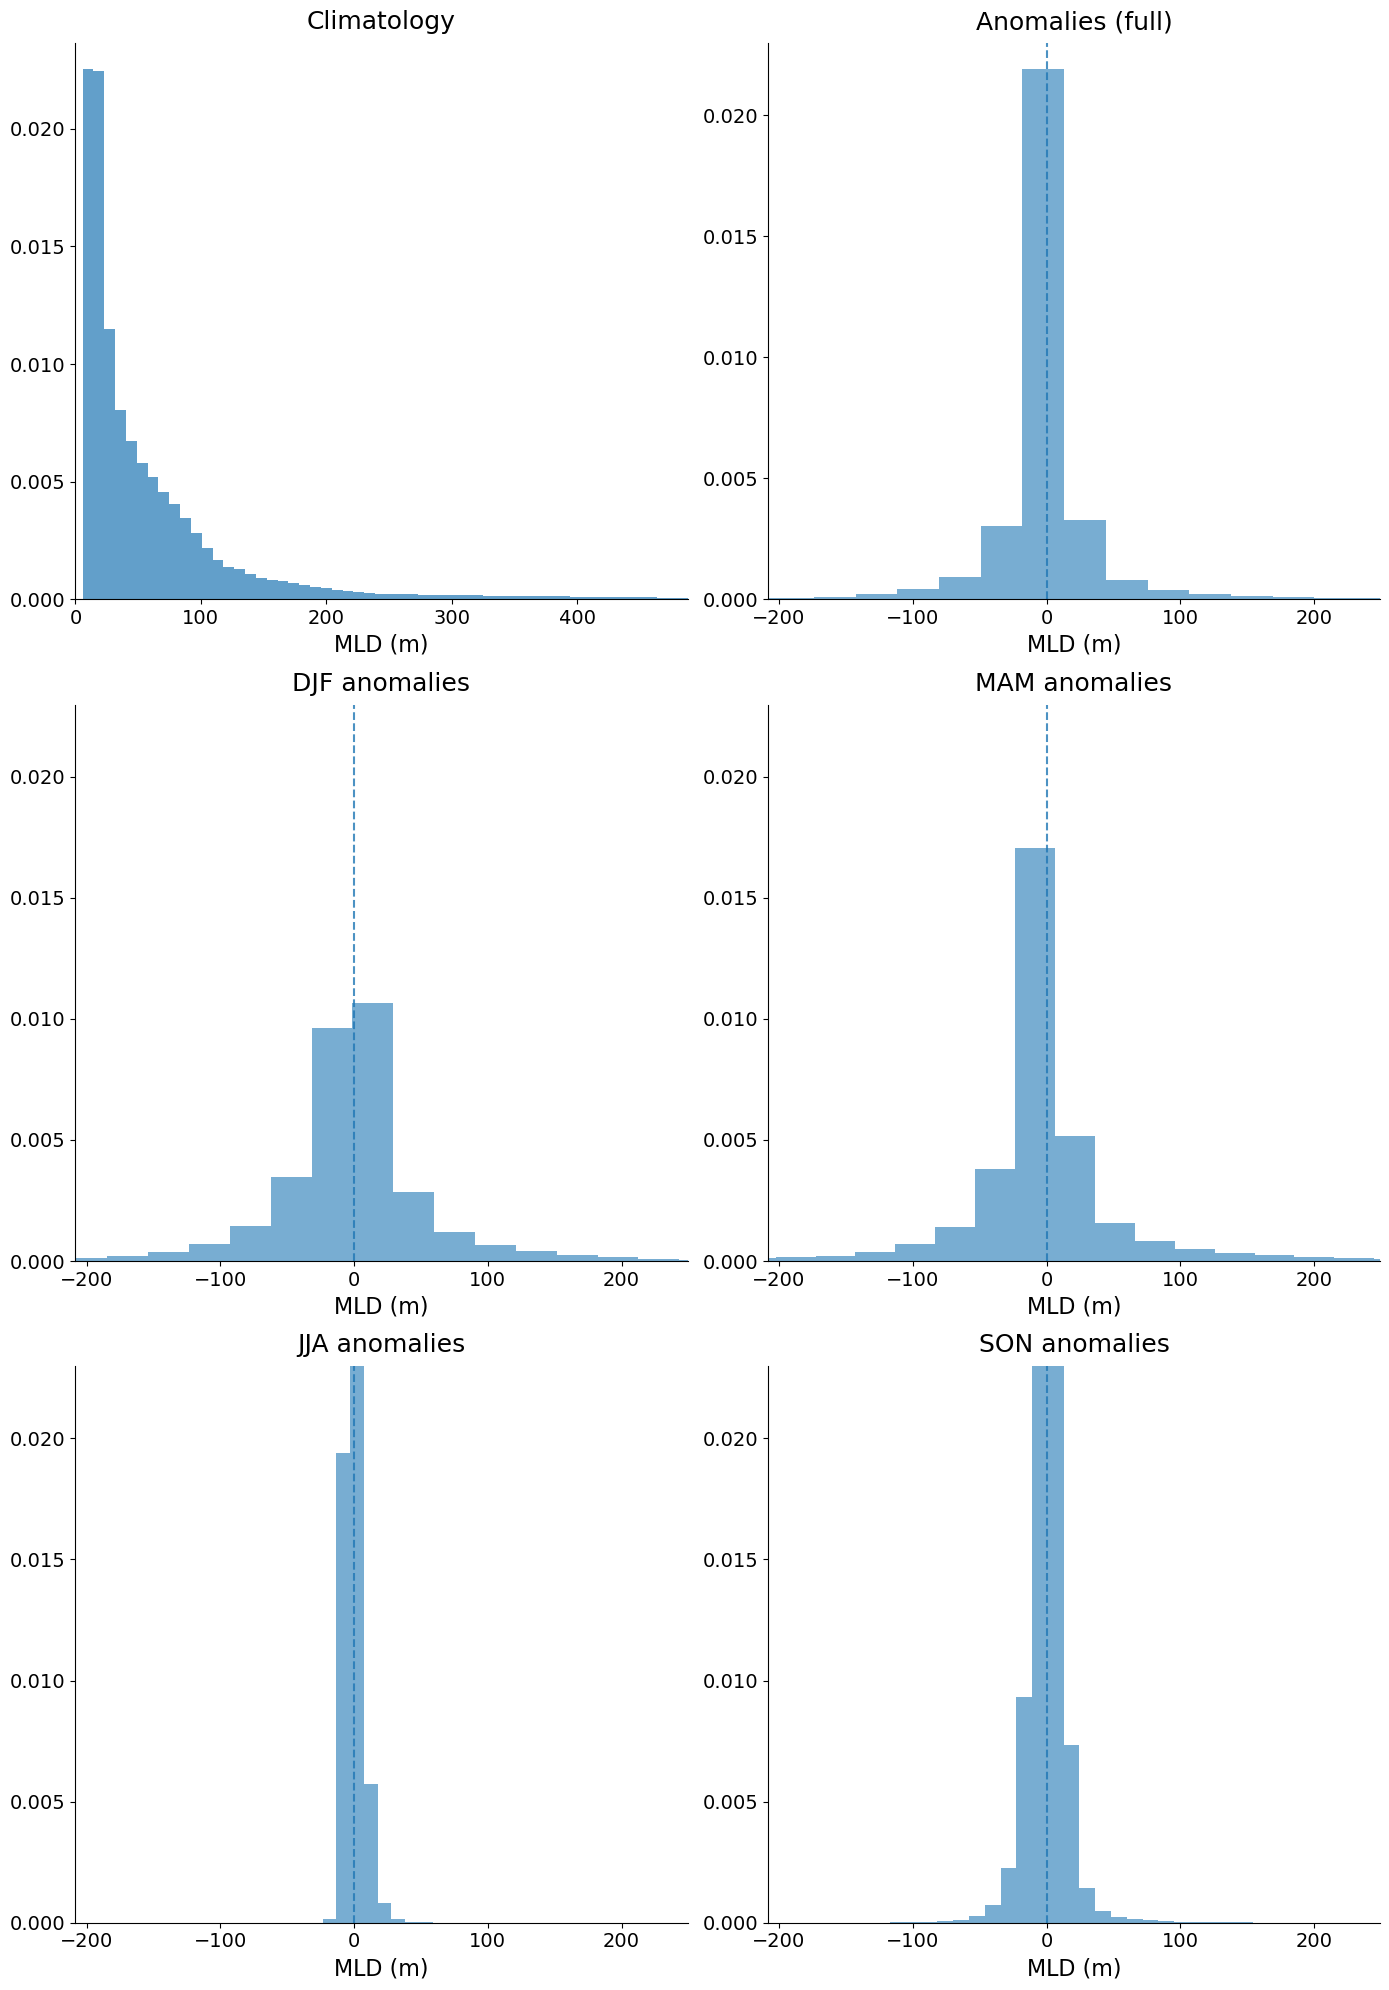

In [8]:
def flatten_valid(da):
    vals = da.values.ravel()
    return vals[~np.isnan(vals)]


# ----------------------------
# Shared anomaly limits
# ----------------------------
anom_vals = flatten_valid(full_anomalies)
x_min, x_max = np.percentile(anom_vals, [0.5, 99.5])
pdf_max = np.histogram(anom_vals, bins=100, density=True)[0].max()


# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 20), sharex=False, sharey=False)

datasets = [
    (climatology, "Climatology"),
    (full_anomalies, "Anomalies (full)"),
    (DJF_anomalies, "DJF anomalies"),
    (MAM_anomalies, "MAM anomalies"),
    (JJA_anomalies, "JJA anomalies"),
    (SON_anomalies, "SON anomalies"),]


for ax, (da, title) in zip(axes.flat, datasets):
    vals = flatten_valid(da)

    # Slightly different styling for climatology
    is_anom = "anomalies" in title.lower()

    ax.hist(vals, bins=100, density=True, histtype="stepfilled", alpha=0.6 if is_anom else 0.7, linewidth=1.2)

    # Titles & labels
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel("MLD (m)", fontsize=16)
    ax.set_ylabel(None)
    ax.tick_params(axis="both", labelsize=14, direction="out")

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if is_anom:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, pdf_max * 1.05)
        ax.axvline(0, linestyle="--", linewidth=1.5, alpha=0.8)

# Climatology x-limits
axes[0, 0].set_xlim(0, np.nanpercentile(flatten_valid(climatology), 99.5))

plt.tight_layout()
plt.show()


## Compute EOFs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to compute EOFs

In [9]:
# ----------------------------------
# Parameters
# ----------------------------------
n_eof_season = 10  # number of EOFs per season
n_eof_full   = 10  # number of EOFs for full dataset


def compute_eofs(anom_data, n_eof, name="Dataset"):
    """
    EOF solver using xarray DataArray
    """

    nt, nlat, nlon = anom_data.shape

    # Cosine-latitude weights
    lat_vals = anom_data.latitude.values
    weights = np.sqrt(np.cos(np.radians(lat_vals)))
    weights_2d = np.broadcast_to(weights[:, np.newaxis], (nlat, nlon))

    # EOF solver
    solver = Eof(anom_data, weights=weights_2d)

    # Extract EOFs, PCs, variance
    eof_patterns = solver.eofs(neofs=n_eof, eofscaling=2)
    pcs = solver.pcs(npcs=n_eof, pcscaling=0)
    explained_var = solver.varianceFraction(neigs=n_eof)

    return eof_patterns, pcs, explained_var


#### EOF + PC Solver

In [10]:
DJF_eof, DJF_pcs, DJF_var = compute_eofs(DJF_anomalies, n_eof_season, "DJF")
MAM_eof, MAM_pcs, MAM_var = compute_eofs(MAM_anomalies, n_eof_season, "MAM")
JJA_eof, JJA_pcs, JJA_var = compute_eofs(JJA_anomalies, n_eof_season, "JJA")
SON_eof, SON_pcs, SON_var = compute_eofs(SON_anomalies, n_eof_season, "SON")

full_eof, full_pcs, full_var = compute_eofs(full_anomalies, n_eof_full, "full")

#### Standardise PCs

In [11]:
# divide by the standard deviation

full_pcs_std = full_pcs / full_pcs.std(dim="time", skipna=True)
DJF_pcs_std = DJF_pcs / DJF_pcs.std(dim="time", skipna=True)
MAM_pcs_std = MAM_pcs / MAM_pcs.std(dim="time", skipna=True)
JJA_pcs_std = JJA_pcs / JJA_pcs.std(dim="time", skipna=True)
SON_pcs_std = SON_pcs / SON_pcs.std(dim="time", skipna=True)

## SCREE PLOTS
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Scree plotting function

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scree(ax, var_fraction, season_name, n_modes=10):

    var = np.array(var_fraction[:n_modes])
    modes = np.arange(1, len(var) + 1)

    var_percent = 100 * var
    cumulative = 100 * np.cumsum(var)

    # Transparent bars
    bars = ax.bar(modes, var_percent, alpha=0.4, edgecolor='black', linewidth=1, zorder=1)

    # Overlay cumulative curve
    ax2 = ax.twinx()
    ax2.plot(modes, cumulative, marker='o', linewidth=2, zorder=3)

    # Formatting
    ax.set_xlabel("EOF Mode")
    ax.set_ylabel("Variance Explained (%)")
    ax2.set_ylabel("Cumulative Variance (%)")

    ax.set_xticks(modes)

    ax.set_ylim(0, max(var_percent) * 1.2)
    ax2.set_ylim(0, 100)

    ax.set_title(season_name)

    # Keep cumulative curve visually on top
    ax.set_zorder(1)
    ax.patch.set_visible(False)


#### Call scree plotting function

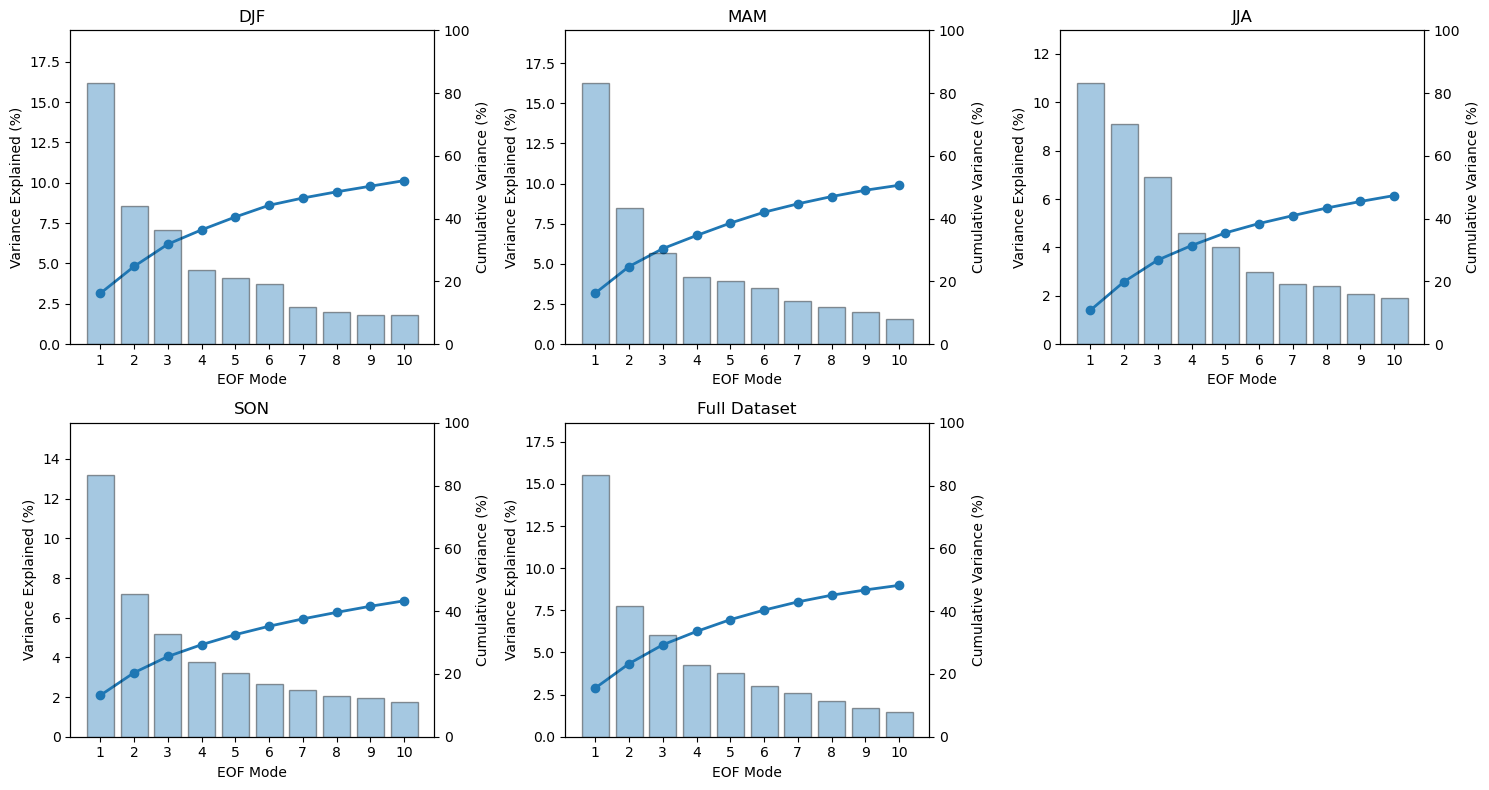

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_scree(axes[0, 0], DJF_var, "DJF")
plot_scree(axes[0, 1], MAM_var, "MAM")
plot_scree(axes[0, 2], JJA_var, "JJA")

plot_scree(axes[1, 0], SON_var, "SON")
plot_scree(axes[1, 1], full_var, "Full Dataset")

# Remove unused last panel
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()


## PLOT EOFs & PCs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Classify data

In [14]:
# ----------------------------------
# Classify data
# ----------------------------------
eof_data = {
    "DJF": {"anom": DJF_anomalies, "eofs": DJF_eof, "pcs": DJF_pcs, "pcs_std":DJF_pcs_std, "var": DJF_var,},
    "MAM": {"anom": MAM_anomalies, "eofs": MAM_eof, "pcs": MAM_pcs, "pcs_std":MAM_pcs_std, "var": MAM_var,},
    "JJA": {"anom": JJA_anomalies,"eofs": JJA_eof, "pcs": JJA_pcs, "pcs_std":JJA_pcs_std, "var": JJA_var,},
    "SON": {"anom": SON_anomalies, "eofs": SON_eof, "pcs": SON_pcs, "pcs_std":SON_pcs_std, "var": SON_var,},
    "full": {"anom": full_anomalies, "eofs": full_eof, "pcs": full_pcs, "pcs_std":full_pcs_std, "var": full_var,},}

#### Select season to plot
<hr style='border: solid 2px red;'>

In [31]:
season = "full"

## PC scatter and PDFs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

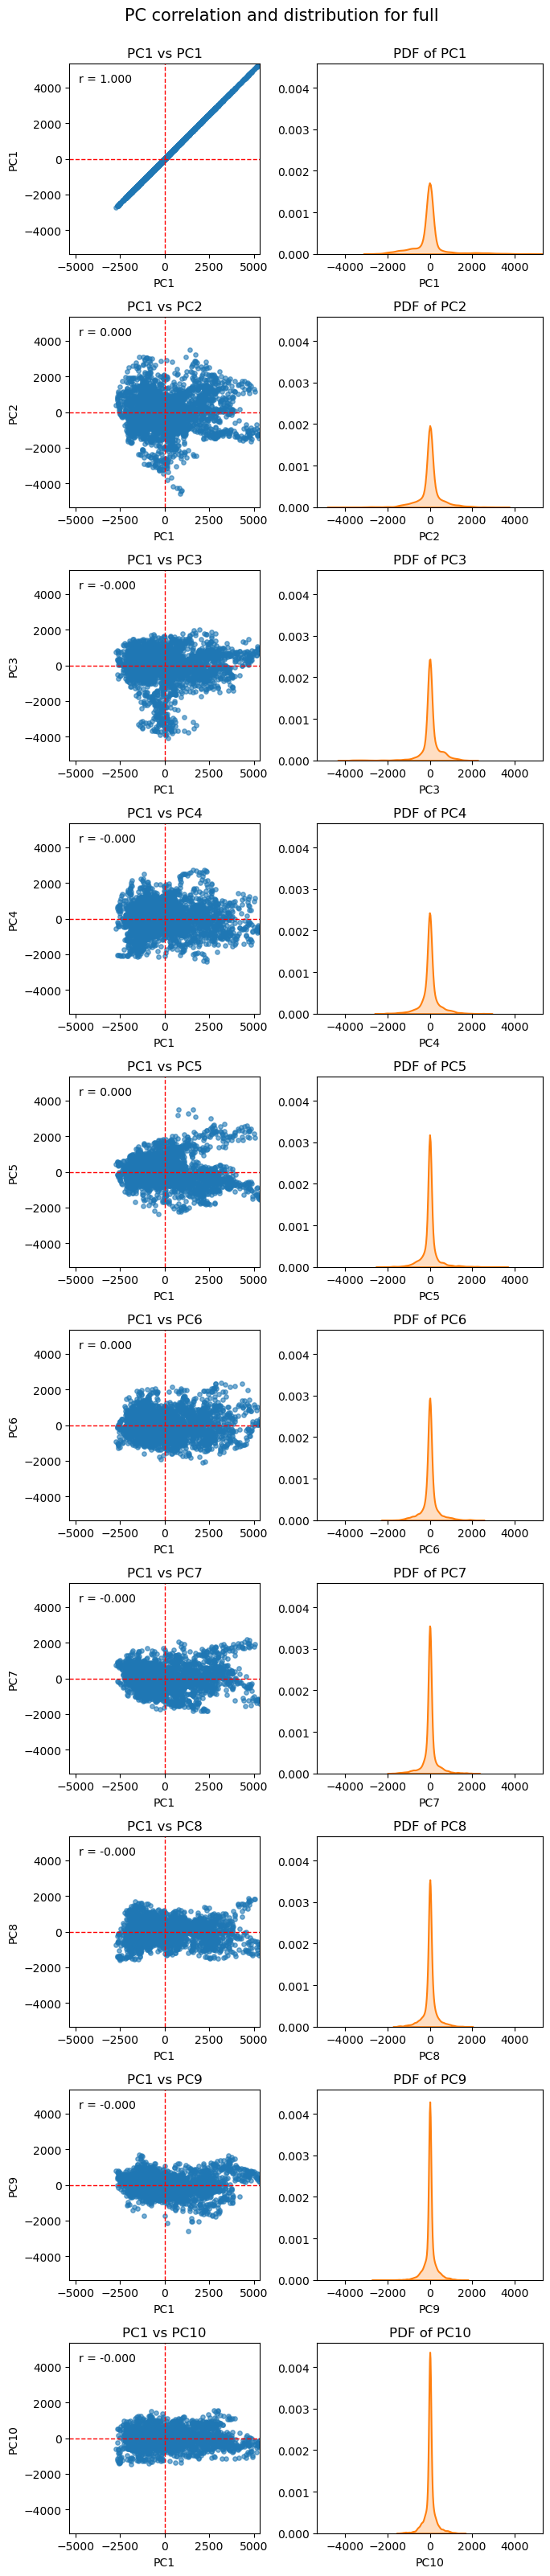

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Pull PCs for season
pcs = eof_data[season]["pcs"]        # raw PCs
n_pcs_to_plot = pcs.shape[1]         # number of EOF modes
reference_pc_index = 0                # PC to plot against in left column (0 = PC1)

# -----------------------
# Compute global limits for square scatter plots
# -----------------------
x_ref = pcs[:, reference_pc_index]
all_pcs_min = pcs[:, :n_pcs_to_plot].min()
all_pcs_max = pcs[:, :n_pcs_to_plot].max()
scatter_limit = max(abs(all_pcs_min), abs(all_pcs_max))
x_min, x_max = -scatter_limit, scatter_limit
y_min, y_max = -scatter_limit, scatter_limit

# -----------------------
# Compute maximum PDF height across all PCs
# -----------------------
pdf_max = 0
for i in range(n_pcs_to_plot):
    kde = sns.kdeplot(pcs[:, i], bw_method='scott', fill=False)
    pdf_max = max(pdf_max, max([line.get_ydata().max() for line in kde.get_lines()]))
    plt.close()  # close temporary plot to avoid showing it

# -----------------------
# Set figure size
# -----------------------
subplot_size = 3
fig_width = 2 * subplot_size + 1
fig_height = n_pcs_to_plot * subplot_size + 2

fig, axes = plt.subplots(
    nrows=n_pcs_to_plot,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'width_ratios':[1,1], 'height_ratios':[1]*n_pcs_to_plot})

fig.subplots_adjust(hspace=0.4, wspace=0.3)

# -----------------------
# Plot each PC
# -----------------------
for i in range(n_pcs_to_plot):
    y = pcs[:, i]

    # Compute Pearson correlation
    r = np.corrcoef(x_ref, y)[0, 1]

    # ----- Left: scatter -----
    ax_scatter = axes[i, 0]
    ax_scatter.scatter(x_ref, y, s=15, alpha=0.6, color='C0')
    ax_scatter.set_xlim(x_min, x_max)
    ax_scatter.set_ylim(y_min, y_max)
    ax_scatter.set_aspect('equal')
    ax_scatter.set_xlabel(f"PC{reference_pc_index+1}")
    ax_scatter.set_ylabel(f"PC{i+1}")
    ax_scatter.set_title(f"PC{reference_pc_index+1} vs PC{i+1}")

    # Red zero lines
    ax_scatter.axhline(0, color='red', linestyle='--', linewidth=1)
    ax_scatter.axvline(0, color='red', linestyle='--', linewidth=1)

    # Add correlation text
    ax_scatter.text(0.05, 0.95, f"r = {r:.3f}", transform=ax_scatter.transAxes, ha='left', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # ----- Right: PDF -----
    ax_pdf = axes[i, 1]
    sns.kdeplot(y, ax=ax_pdf, fill=True, color='C1', linewidth=1.5)
    ax_pdf.set_xlim(x_min, x_max)
    ax_pdf.set_ylim(0, pdf_max * 1.05)  # uniform y-axis for all PDFs
    ax_pdf.set_xlabel(f"PC{i+1}")
    ax_pdf.set_ylabel(None)
    ax_pdf.set_title(f"PDF of PC{i+1}")

# -----------------------
# Save or show figure
# -----------------------
fig.suptitle(f"PC correlation and distribution for {season}", fontsize=15, y=1)
save_fname = f"PC analysis for {season}.png"
# plt.savefig(save_fname, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


## PLOT EOFs & PCs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### EOF & PC plotting function

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec

# Pull data from your dictionary
anom_data = eof_data[season]["anom"]
eofs = eof_data[season]["eofs"]
pcs = eof_data[season]["pcs"]
explained_var = eof_data[season]["var"]

def plot_seasonal_eofs_pcs(season_name, anom_data, eofs, pcs, explained_var, save_path=None):
    """
    Plot the first 3 EOFs for a season with:
    - Column 1: EOF map
    - Column 2: yearly-averaged PCs with mean line
    - Column 3: day-of-year averaged PCs with mean and zero line
    """

    lats = anom_data.latitude.values
    lons = anom_data.longitude.values
    
    n_eof_to_plot = min(3, eofs.shape[0])
    pcs = pcs[:, :n_eof_to_plot]
    
    pcs_da = xr.DataArray(pcs, dims=("time", "EOF"), coords={"time": anom_data.time, "EOF": np.arange(n_eof_to_plot)})

    # Yearly-averaged PCs
    pcs_yearly = pcs_da.groupby("time.year").mean(dim="time")

    # Day-of-year averaged PCs
    pcs_avg_doy = pcs_da.groupby(anom_data.day365).mean(dim="time")

    # Symmetric color scale for EOFs, fully adaptive
    season_max = np.nanmax(np.abs(eofs[:n_eof_to_plot]))
    vmax = season_max
    vmin = -season_max


    # Figure + GridSpec
    fig = plt.figure(figsize=(18, 4 * n_eof_to_plot))
    gs = gridspec.GridSpec(n_eof_to_plot, 3, width_ratios=[1, 1, 1], wspace=0.15, hspace=0.1)

    ax_pc_ref = None
    ax_avg_ref = None

    for i in range(n_eof_to_plot):

        # ------------------------
        # Column 1: EOF map
        # ------------------------
        ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        eof_map = eofs[i, :, :]
        pcm = ax_map.pcolormesh(lons, lats, eof_map, vmin=vmin, vmax=vmax, cmap="RdBu_r",
                                shading="auto", transform=ccrs.PlateCarree())
        ax_map.coastlines()
        ax_map.add_feature(cfeature.BORDERS)
        ax_map.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
        ax_map.set_aspect('auto')
        ax_map.text(-0.05, 0.5, f"EOF {i+1}\n{explained_var[i]*100:.1f}%", 
                    va='center', ha='right', fontsize=14, transform=ax_map.transAxes)

        # ------------------------
        # Column 2: Yearly-averaged PCs
        # ------------------------
        if ax_pc_ref is None:
            ax_pc = fig.add_subplot(gs[i, 1])
            ax_pc_ref = ax_pc
        else:
            ax_pc = fig.add_subplot(gs[i, 1], sharex=ax_pc_ref)

        pc_mean = pcs_da[:, i].mean(dim="time").item()
        ax_pc.plot(pcs_yearly.year.values, pcs_yearly[:, i], color="tab:blue", marker="o", linestyle="-", markersize=4)
        ax_pc.axhline(pc_mean, color="black", linestyle="--", linewidth=1)
        
        # Mean annotation
        ax_pc.text(0.95, 0.05, f"mean = {pc_mean:.3e}", transform=ax_pc.transAxes,
                   fontsize=12, verticalalignment='bottom', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        yvals = pcs_yearly[:, i].values
        ylim = 1.1 * np.nanmax(np.abs(yvals))
        ax_pc.set_ylim(-ylim, ylim)

        if i != n_eof_to_plot - 1:
            plt.setp(ax_pc.get_xticklabels(), visible=False)
        else:
            years = pcs_yearly.year.values
            ax_pc.set_xticks(years[::4])
            ax_pc.set_xticklabels(years[::4])
            ax_pc.tick_params(axis="x", rotation=45)

        # ------------------------
        # Column 3: DOY-averaged PCs
        # ------------------------
        if ax_avg_ref is None:
            ax_avg = fig.add_subplot(gs[i, 2])
            ax_avg_ref = ax_avg
        else:
            ax_avg = fig.add_subplot(gs[i, 2], sharex=ax_avg_ref)

        # Column 3: DOY-averaged PCs
        ax_avg.plot(np.arange(1, len(pcs_avg_doy) + 1), pcs_avg_doy[:, i], color="tab:red")
        
        # Zero line
        ax_avg.axhline(0, color='black', linestyle='--', linewidth=1)
        
        # Mean of the DOY-averaged line
        pc_mean_doy = pcs_avg_doy[:, i].mean().item()
        ax_avg.axhline(pc_mean_doy, color='black', linestyle=':', linewidth=1)
        
        # Annotate
        ax_avg.text(0.95, 0.05, f"mean = {pc_mean_doy:.3e}", transform=ax_avg.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))



        yvals_avg = pcs_avg_doy[:, i].values
        ylim_avg = 1.1 * np.nanmax(np.abs(yvals_avg))
        ax_avg.set_ylim(-ylim_avg, ylim_avg)

        if i != n_eof_to_plot - 1:
            plt.setp(ax_avg.get_xticklabels(), visible=False)
        else:
            ax_avg.set_xticks(np.arange(0, len(pcs_avg_doy), 30))
            ax_avg.tick_params(axis='x', rotation=45)

    # ----------------------------------
    # Shared colorbar
    # ----------------------------------
    cbar_ax = fig.add_axes([0.1, 0.01, 0.8, 0.03]) 
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("EOF amplitude (m/stdev)", fontsize=14)

    # Column titles
    fig.text(0.165, 0.9, "EOF maps", ha='center', fontsize=18, fontweight='bold')
    fig.text(0.5, 0.9, "Yearly-averaged PCs", ha='center', fontsize=18, fontweight='bold')
    fig.text(0.835, 0.9, "DOY-averaged PCs", ha='center', fontsize=18, fontweight='bold')

    # Final touches
    fig.suptitle(f"First 3 EOFs and PCs for {season}", fontsize=22, y=0.98)
    fig.subplots_adjust(top=0.88, left=0.05, right=0.95, hspace=0.1)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()


#### Call EOF & PC plotting function

Figure saved to 3PCs for full


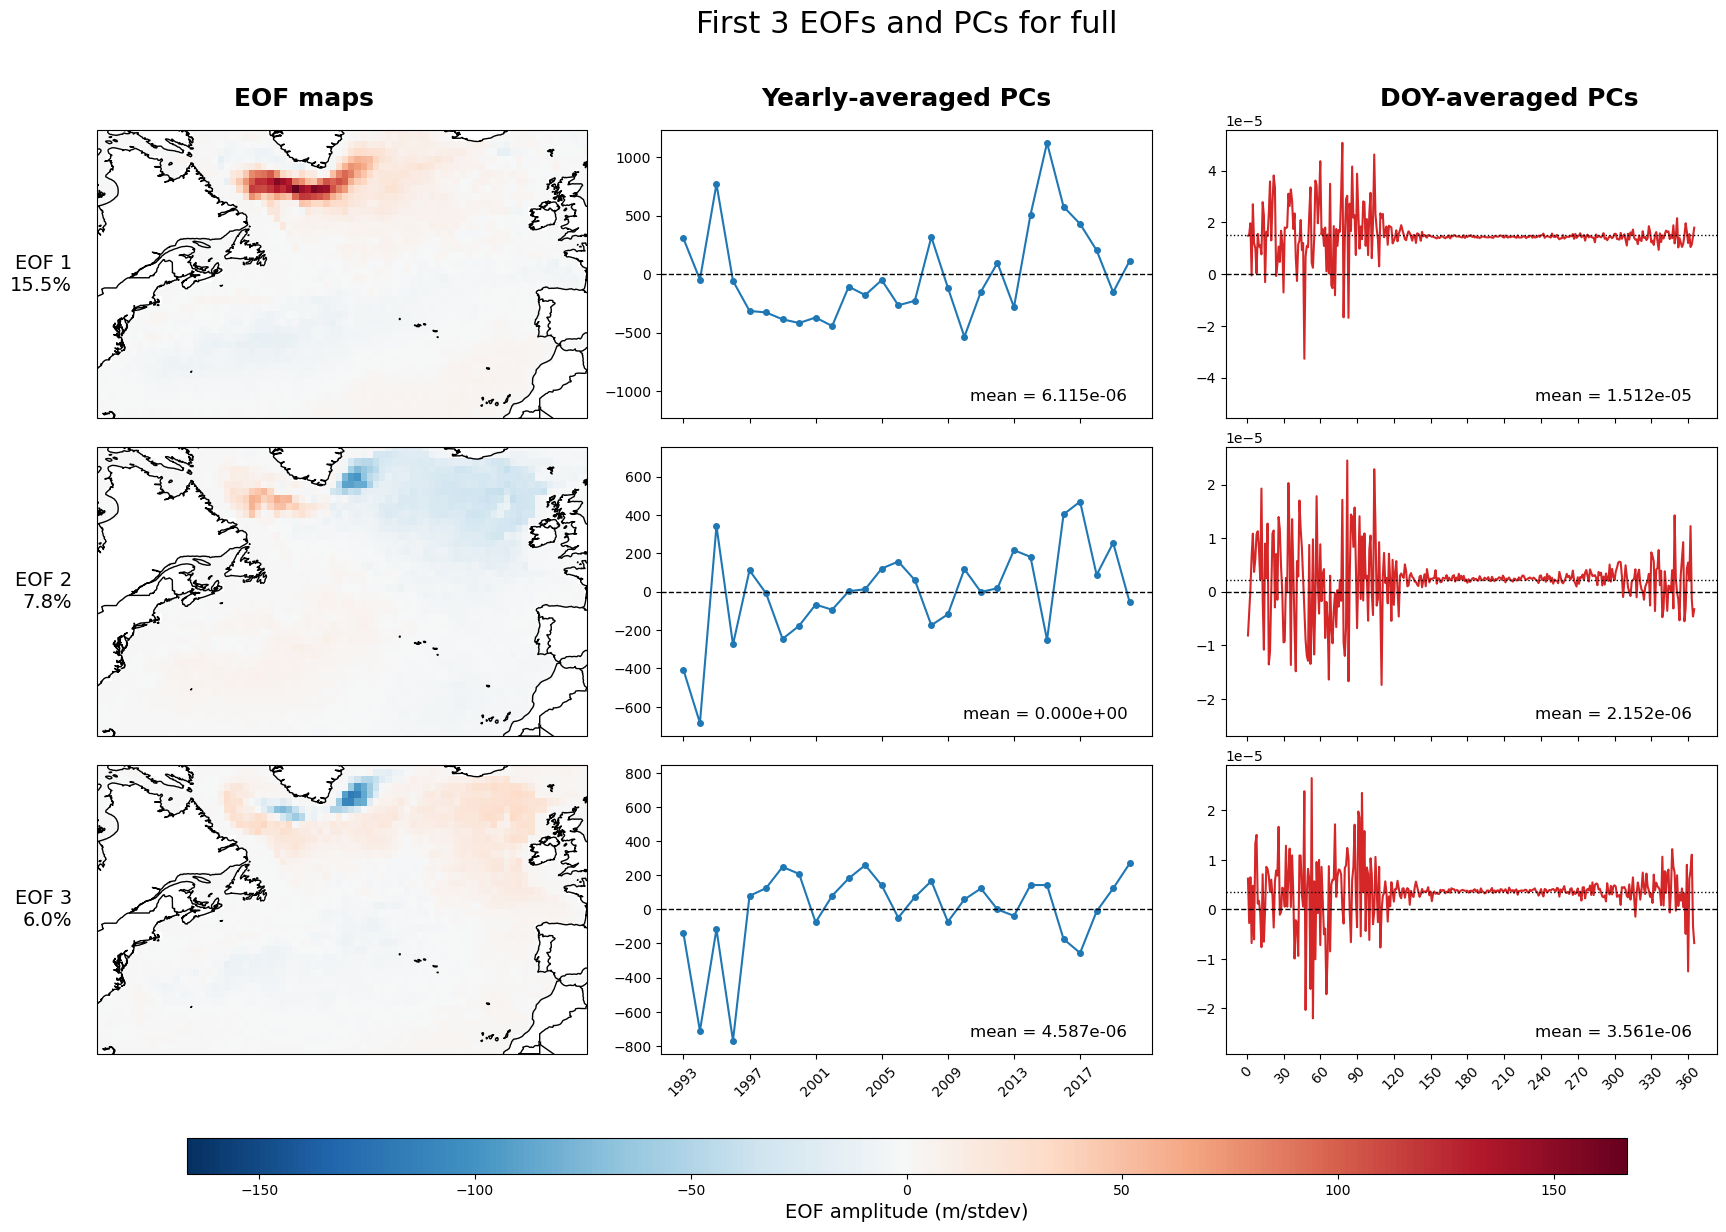

In [34]:
plot_seasonal_eofs_pcs(season, anom_data, eofs, pcs, explained_var, save_path=f"3PCs for {season}")